In [7]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 10),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from MDP.USTFutures.USTFutureOptionMDP import USTFutureOptionMDP
from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP

from TB.TimeseriesBuilder import TimeseriesBuilder
from TB.USTFutureOptionsTB import USTFutureOptionsTB 
from TB.IRSwaptionsTB import IRSwaptionsTB 

from Query.USTFutureOptions import USTFutureOptionQuery, USTFutureOptionStructure, USTFutureOptionValue
from Query.IRSwaptions import IRSwaptionQuery, IRSwaptionStructure, IRSwaptionValue

from BT.misc import ql_cal_date_range

In [6]:
# otc_listed_vol_tb = TimeseriesBuilder(
#     irswaptions_tb=IRSwaptionsTB(
#         IRSwaptionMDP(
#             source="GSQUANT-QL",
#             curve_source="ERIS_EOD_LIVE-QL_BASIC",
#         ),
#         show_tqdm=True,
#     ),
#     ustfutureoptions_tb=USTFutureOptionsTB(USTFutureOptionMDP(source="USTFO_DUAL-QL"), show_tqdm=True),
#     # ustfutureoptions_tb=USTFutureOptionsTB(USTFutureOptionMDP(source="BARCHART_USTFO-QL"), show_tqdm=True),
# )

In [7]:
# start = datetime.date(2025, 3, 15)
# end = datetime.date(2026, 3, 9)

# queries = [
    # USTFutureOptionQuery(symbol="TY_30|ATMS", value=USTFutureOptionValue.IV_NORMAL_BPS),
    # USTFutureOptionQuery(symbol="US_30|ATMS", value=USTFutureOptionValue.IV_NORMAL_BPS),

    # USTFutureOptionQuery(symbol="TYM26|ATMS", value=USTFutureOptionValue.IV_NORMAL_BPS),
    # IRSwaptionQuery(
    #     curve="USD-SOFR-1D",
    #     shorthand="1m7y",
    #     structure=IRSwaptionStructure.STRADDLE,
    #     strike="ATMF",
    #     value=IRSwaptionValue.NVOL,
    # ),
# ]

# df = otc_listed_vol_tb.get_timeseries(
#     start=start,
#     end=end,
#     queries=queries,
#     drop_multilevel_cols=True,
#     # ignore_cache=True
# )
# df

In [8]:
# plot, fig, ax, ax2, legend = make_secondary_axis_plot()
# plot(df["TY_30|ATMS OUTRIGHT IV_NORMAL_BPS"], which="left")
# # plot(df["USD-SOFR-1D 1Mx7Y STRADDLE BUY ATMF NVOL"], which="left")
# legend(show_date=True, loc="lower left")
# plt.show()

In [14]:
# python MDP/USTFutures/warm_ustfo_cache_parallel.py --start 2025-01-06 --end 2025-01-10 --chunks 5 --workers 5 --heartbeat-seconds 30 --report-json cache/ustfo_cache_warm_report.json

In [3]:
ustfo_bc_mdp = USTFutureOptionMDP(source="BARCHART_USTFO-QL")
ustfo_qs_mdp = USTFutureOptionMDP(source="USTFO_DUAL-QL")

In [ ]:
# as_of = datetime.date(2026, 3, 6)

# out = ustfo_bc_mdp.get_pricer({
#     "endpoint": "option_snapshot",
#     "symbols": ["TYM26|ATMS"],  
#     "timestamp": as_of,
#     "show_tqdm": True,
#     "use_ql_calculator": True,
# 	# "force_refresh": True
# })

# pr = next(iter(out.values()))[0]
# print("resolved_symbol:", pr.symbol())
# print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
# print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())

In [6]:
as_of = datetime.date(2026, 3, 6)

out = ustfo_qs_mdp.get_pricer({
    "endpoint": "option_snapshot",
    "symbols": ["TY_30|ATMS"],  
    "timestamp": as_of,
    "show_tqdm": True,
    "use_ql_calculator": True,
})
out
pr = next(iter(out.values()))[0]
print("resolved_symbol:", pr.symbol())
print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())

FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 1/1 [00:00<00:00,  2.27it/s]


resolved_symbol: TY_30|ATMS
price: 1.3344930264703276 iv_normal_bps: 89.5200369563612
delta: 0.029646833026165054 gamma: 0.4741296229814184 vega: 0.22788680461562813 theta: -8.057048097608215


Forward: 96.815 (rate: 3.185%)
Expiry: 2026-12-16, TTE: 0.7918y
SABR: α=0.0469, ρ=0.2426, ν=1.8479
Strikes: 32

--- Breeden-Litzenberger ---
Mean: 3.132%, Std: 0.701%
Skew: 0.048, Kurt: 6.694
Percentiles: 5th=1.486%, 50th=3.139%, 95th=4.042%

--- Gaussian Mixture (RMSE: 0.012170) ---
  3 hikes (4.39%): 2.8%  (σ=200.0bp)
  1 cut (3.39%): 36.7%  (σ=8.8bp)
  2 cuts (3.14%): 44.3%  (σ=7.9bp)
  4 cuts (2.64%): 16.2%  (σ=200.0bp)


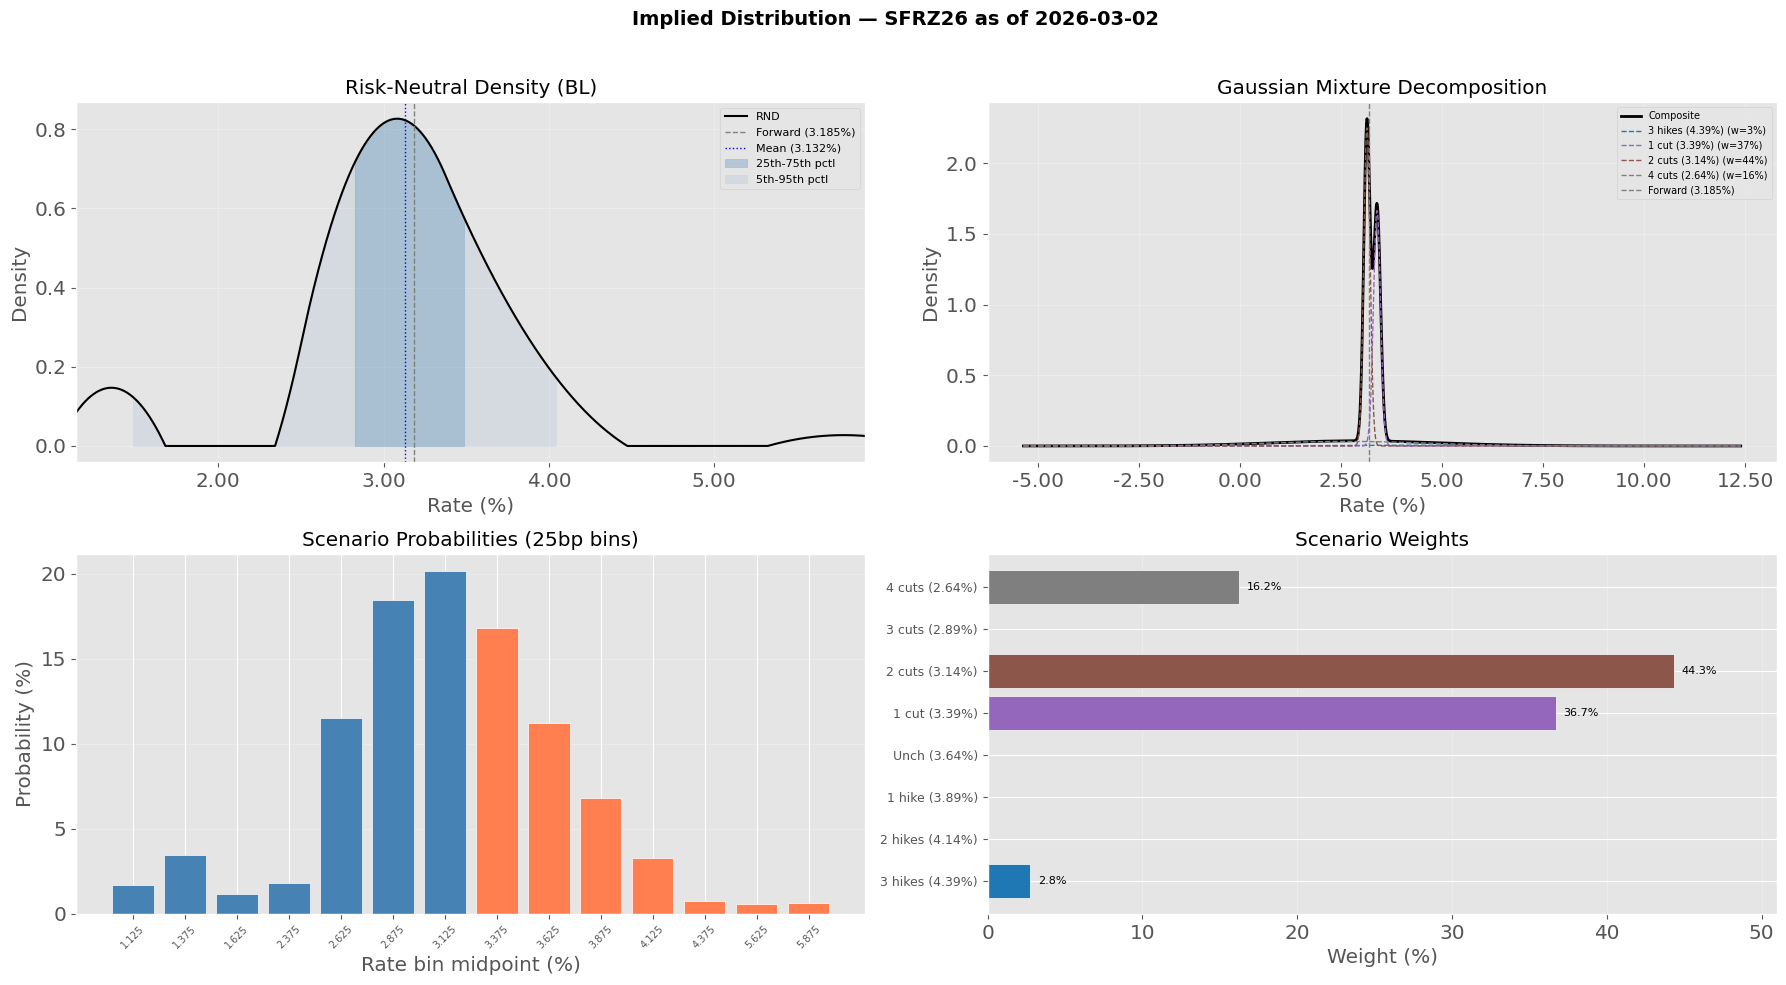

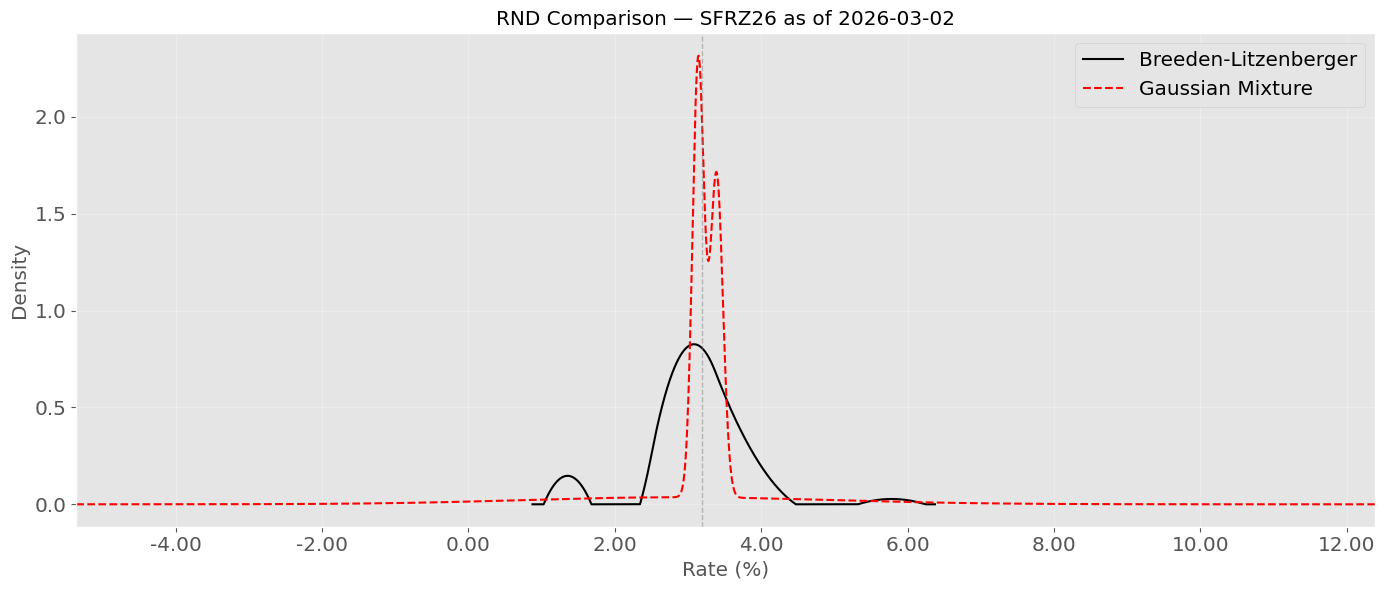

In [18]:
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution,
    FedScenarioConfig,
    plot_snapshot_dashboard,
    plot_rnd_comparison,
)

# 1. Fetch SABR smile with all listed strikes
mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
smile = mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 3, 2),
    "strike_offsets_bps": "listed",
    "show_tqdm": True,
})

print(f"Forward: {smile.params.forward_price} (rate: {smile.params.forward_rate:.3f}%)")
print(f"Expiry: {smile.params.expiry_date}, TTE: {smile.params.time_to_expiry:.4f}y")
print(f"SABR: α={smile.params.alpha:.4f}, ρ={smile.params.rho:.4f}, ν={smile.params.nu:.4f}")
print(f"Strikes: {len(smile.points)}")

# 2. Define Fed scenarios (adjust current_rate to match current Fed funds)
scenarios = FedScenarioConfig.default_sofr_scenarios(
    current_rate=3.64,
    n_cuts_range=[-3, -2, -1, 0, 1, 2, 3, 4],
    default_std_bps=None,  # optimize std devs
)

# 3. Extract both BL and GM distributions
dist = SFRImpliedDistribution(scenario_config=scenarios)
snapshot = dist.extract(smile)

# 4. Print BL summary
bl = snapshot.bl_result
print(f"\n--- Breeden-Litzenberger ---")
print(f"Mean: {bl.mean_rate:.3f}%, Std: {bl.std_rate:.3f}%")
print(f"Skew: {bl.skewness:.3f}, Kurt: {bl.kurtosis:.3f}")
print(f"Percentiles: 5th={bl.percentile(5):.3f}%, 50th={bl.percentile(50):.3f}%, 95th={bl.percentile(95):.3f}%")

# 5. Print GM scenario weights
gm = snapshot.gm_result
print(f"\n--- Gaussian Mixture (RMSE: {gm.rmse_price:.6f}) ---")
for s, w, std in zip(gm.scenarios, gm.weights, gm.fitted_std_rates):
    if w > 0.01:
        print(f"  {s.label}: {w:.1%}  (σ={std*100:.1f}bp)")

# 6. Plot dashboard
fig = plot_snapshot_dashboard(snapshot)
fig.savefig("sfrz26_implied_dist_20260311.png", dpi=150, bbox_inches="tight")

# 7. Overlay comparison
fig2 = plot_rnd_comparison(bl, gm)


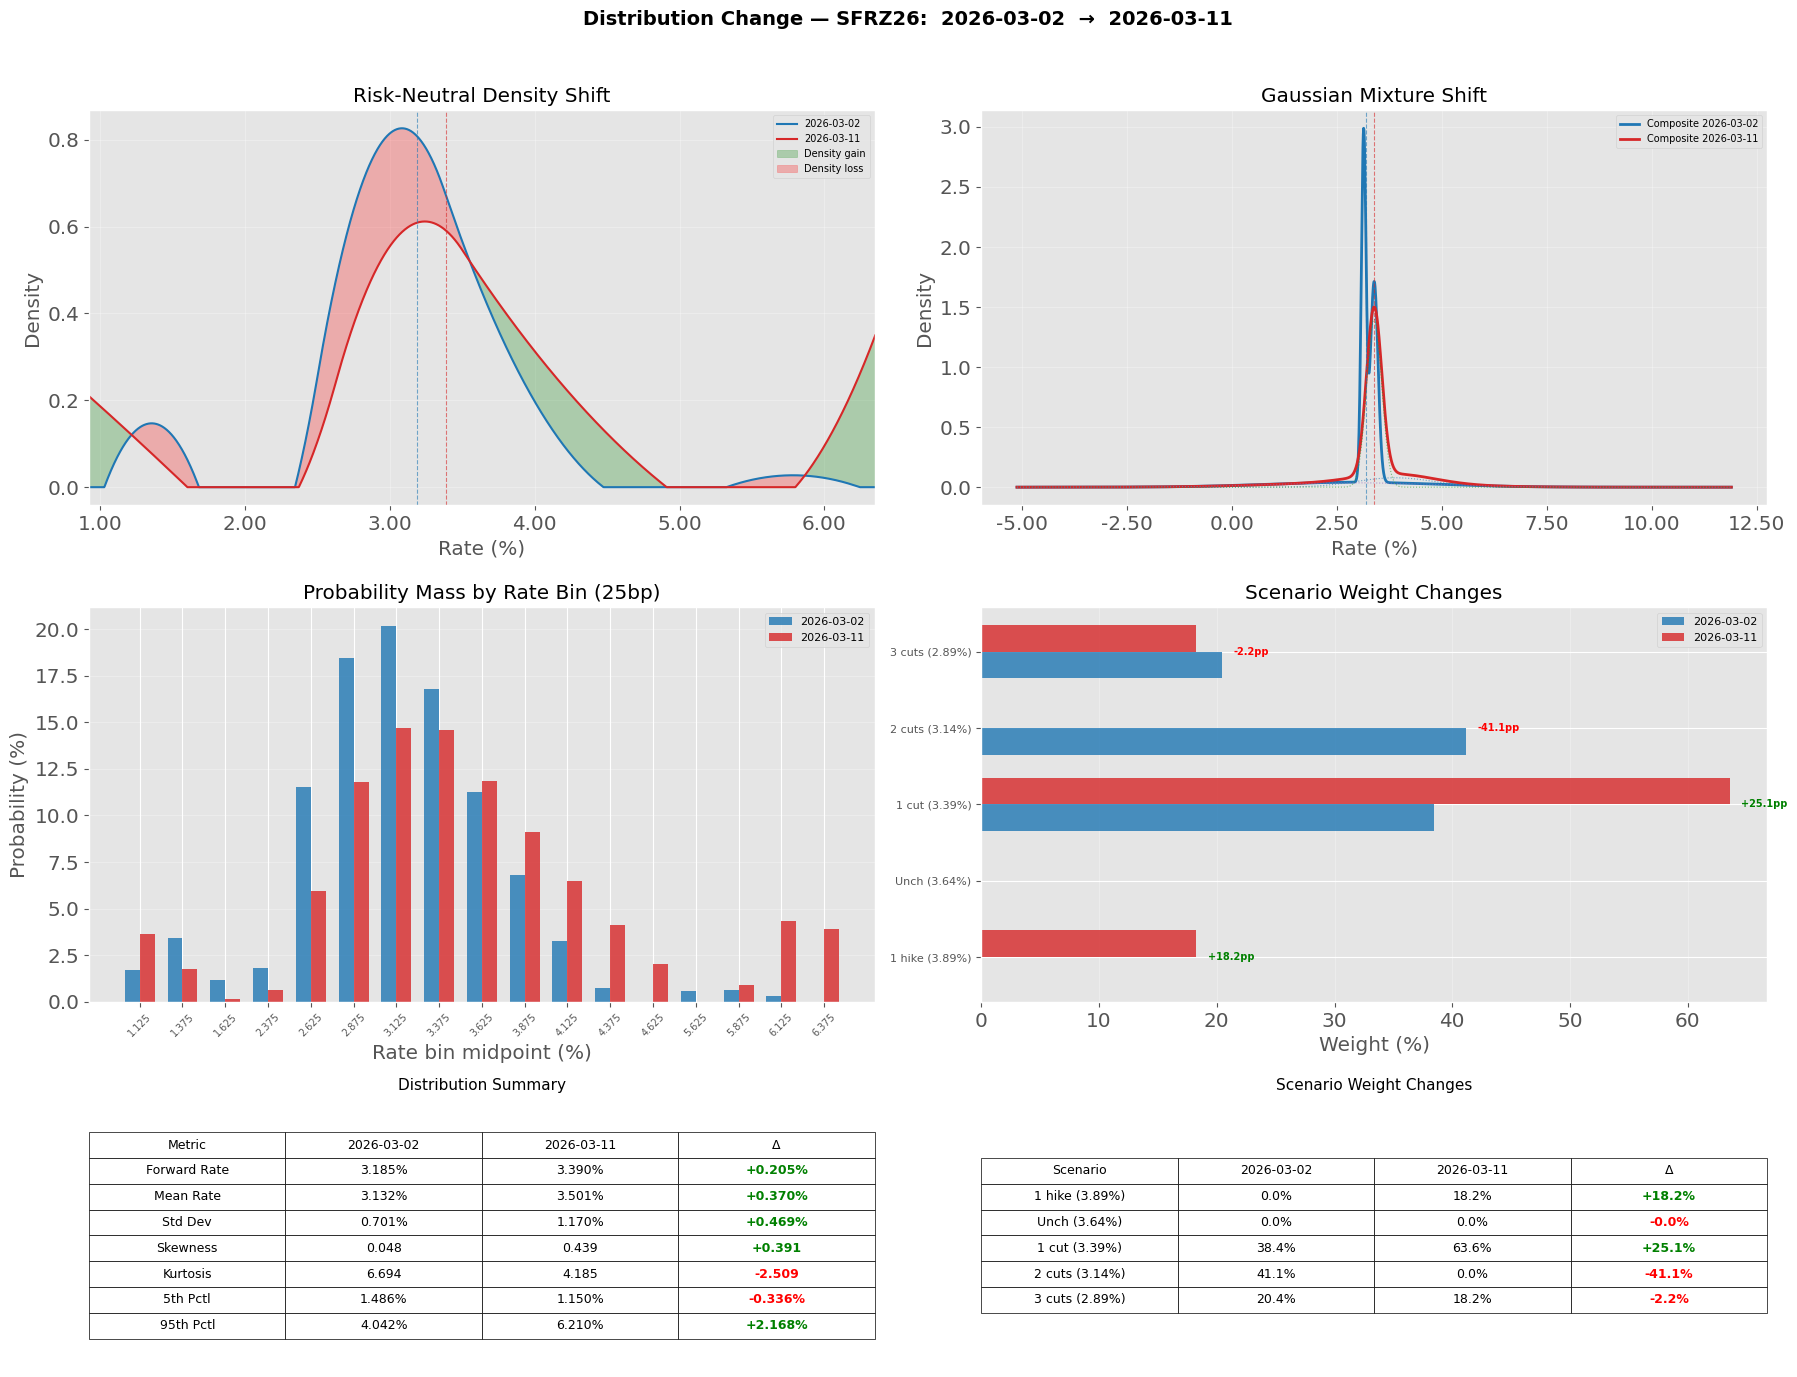

In [20]:
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution, FedScenarioConfig, plot_distribution_change
)
config = FedScenarioConfig.default_sofr_scenarios(
    current_rate=3.64, n_cuts_range=[-1, 0, 1, 2, 3]
)
dist = SFRImpliedDistribution(scenario_config=config)

mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
smile_mar2 = mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 3, 2),
    "strike_offsets_bps": "listed",
    "show_tqdm": True,
})
smile_mar11 = mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 3, 11),
    "strike_offsets_bps": "listed",
    "show_tqdm": True,
})

snap_before, snap_after = dist.compare(smile_mar2, smile_mar11)
fig = plot_distribution_change(snap_before, snap_after)

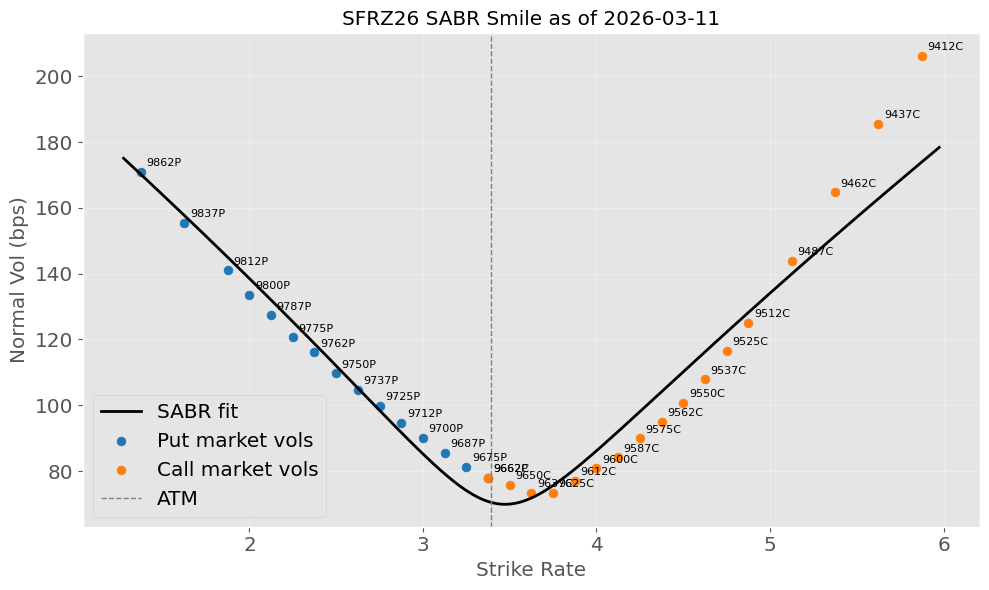

In [21]:
smile = smile_mar11

pts = sorted(smile.points, key=lambda p: p.strike_rate)
call_pts = [p for p in pts if p.right == "C"]
put_pts = [p for p in pts if p.right == "P"]

# Smooth strike grid in rate space
x_min = min(p.strike_rate for p in pts) - 0.10
x_max = max(p.strike_rate for p in pts) + 0.10
strike_grid = np.linspace(x_min, x_max, 400)

# Model vols from fitted SABR smile
sabr_vols_bps = smile.normal_vol(
    strike_grid,
    strike_space="rate",
    vol_units="bps",
)

fig, ax = plt.subplots(figsize=(10, 6))

# Smooth SABR curve
ax.plot(
    strike_grid,
    sabr_vols_bps,
    color="black",
    lw=2,
    label="SABR fit",
)

# Market vols
ax.scatter(
    [p.strike_rate for p in put_pts],
    [p.iv_normal_bps for p in put_pts],
    color="tab:blue",
    s=40,
    label="Put market vols",
)
ax.scatter(
    [p.strike_rate for p in call_pts],
    [p.iv_normal_bps for p in call_pts],
    color="tab:orange",
    s=40,
    label="Call market vols",
)

ax.axvline(
    smile.params.forward_rate,
    color="gray",
    ls="--",
    lw=1,
    label="ATM",
)

for p in pts:
    ax.annotate(
        p.label.split("|")[-1],
        (p.strike_rate, p.iv_normal_bps),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title(f"{smile.symbol} SABR Smile as of {smile.params.as_of}")
ax.set_xlabel("Strike Rate")
ax.set_ylabel("Normal Vol (bps)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

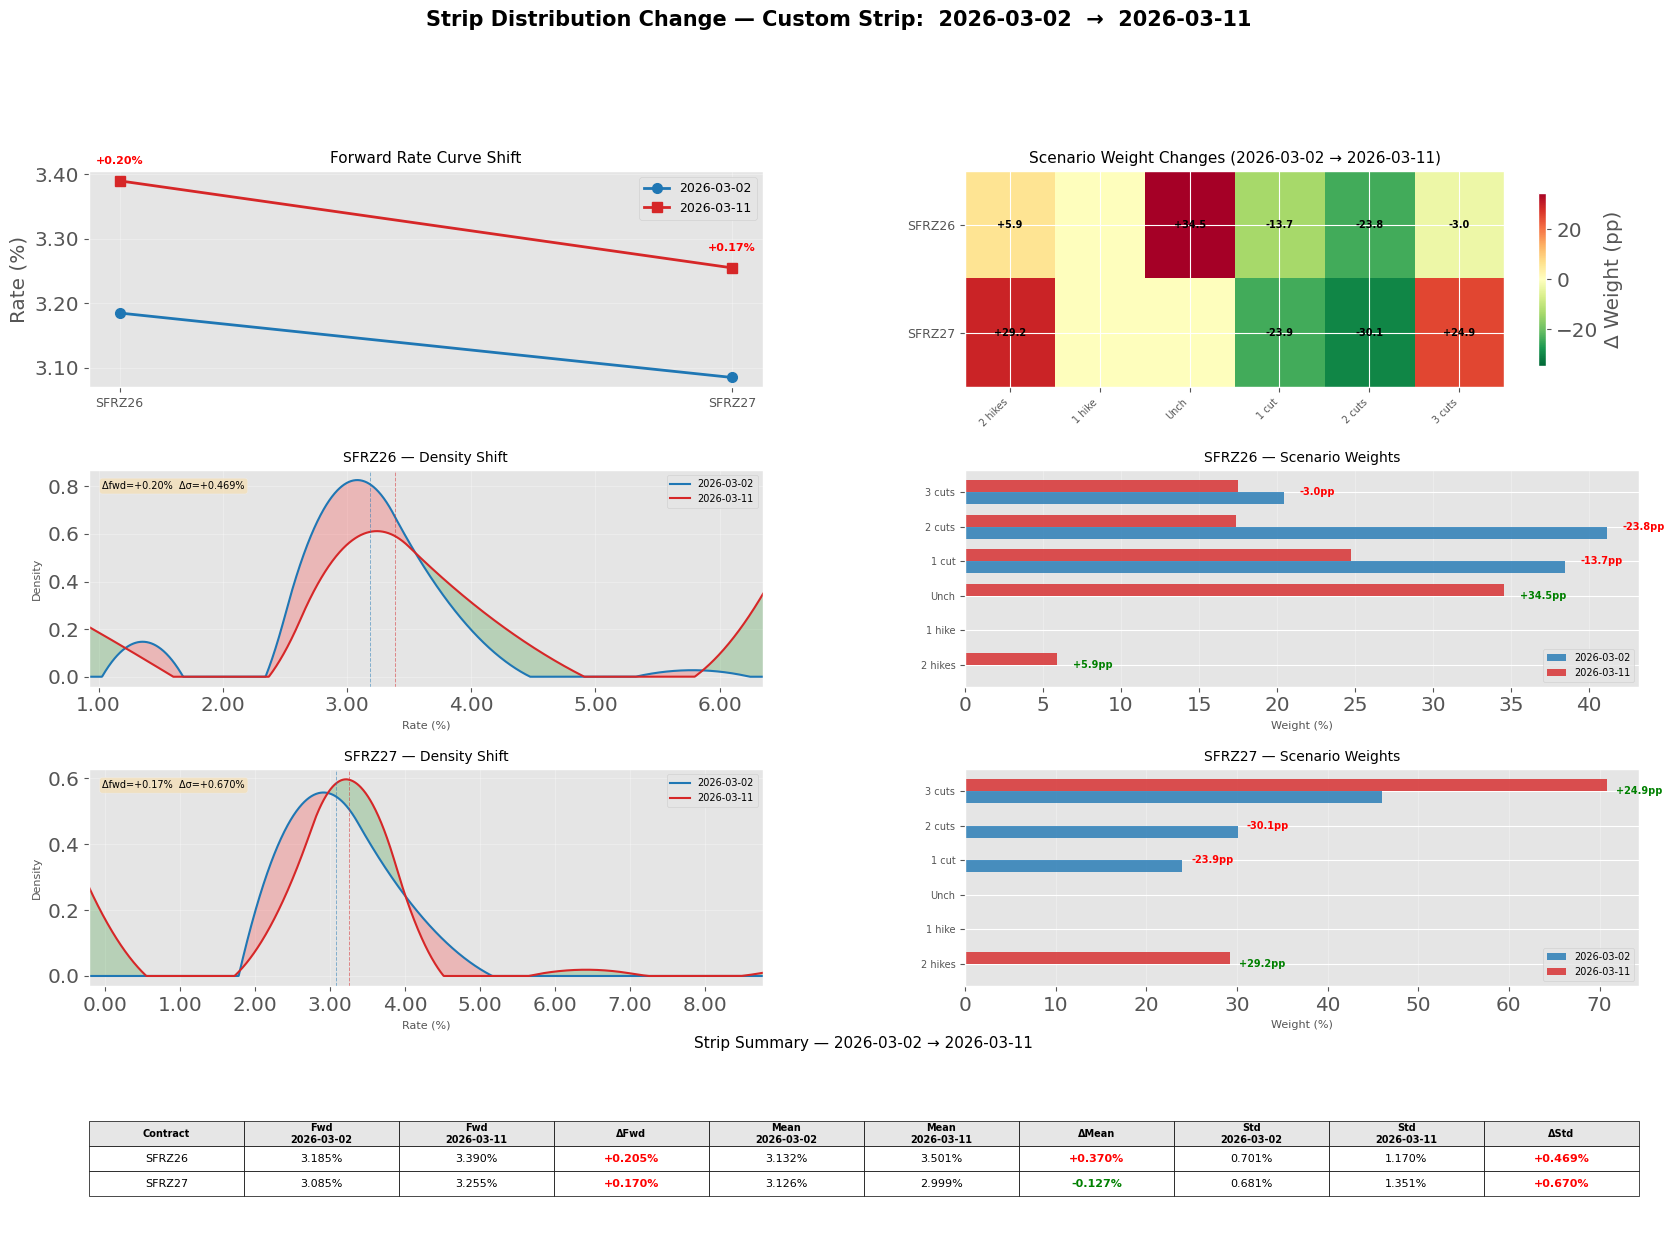

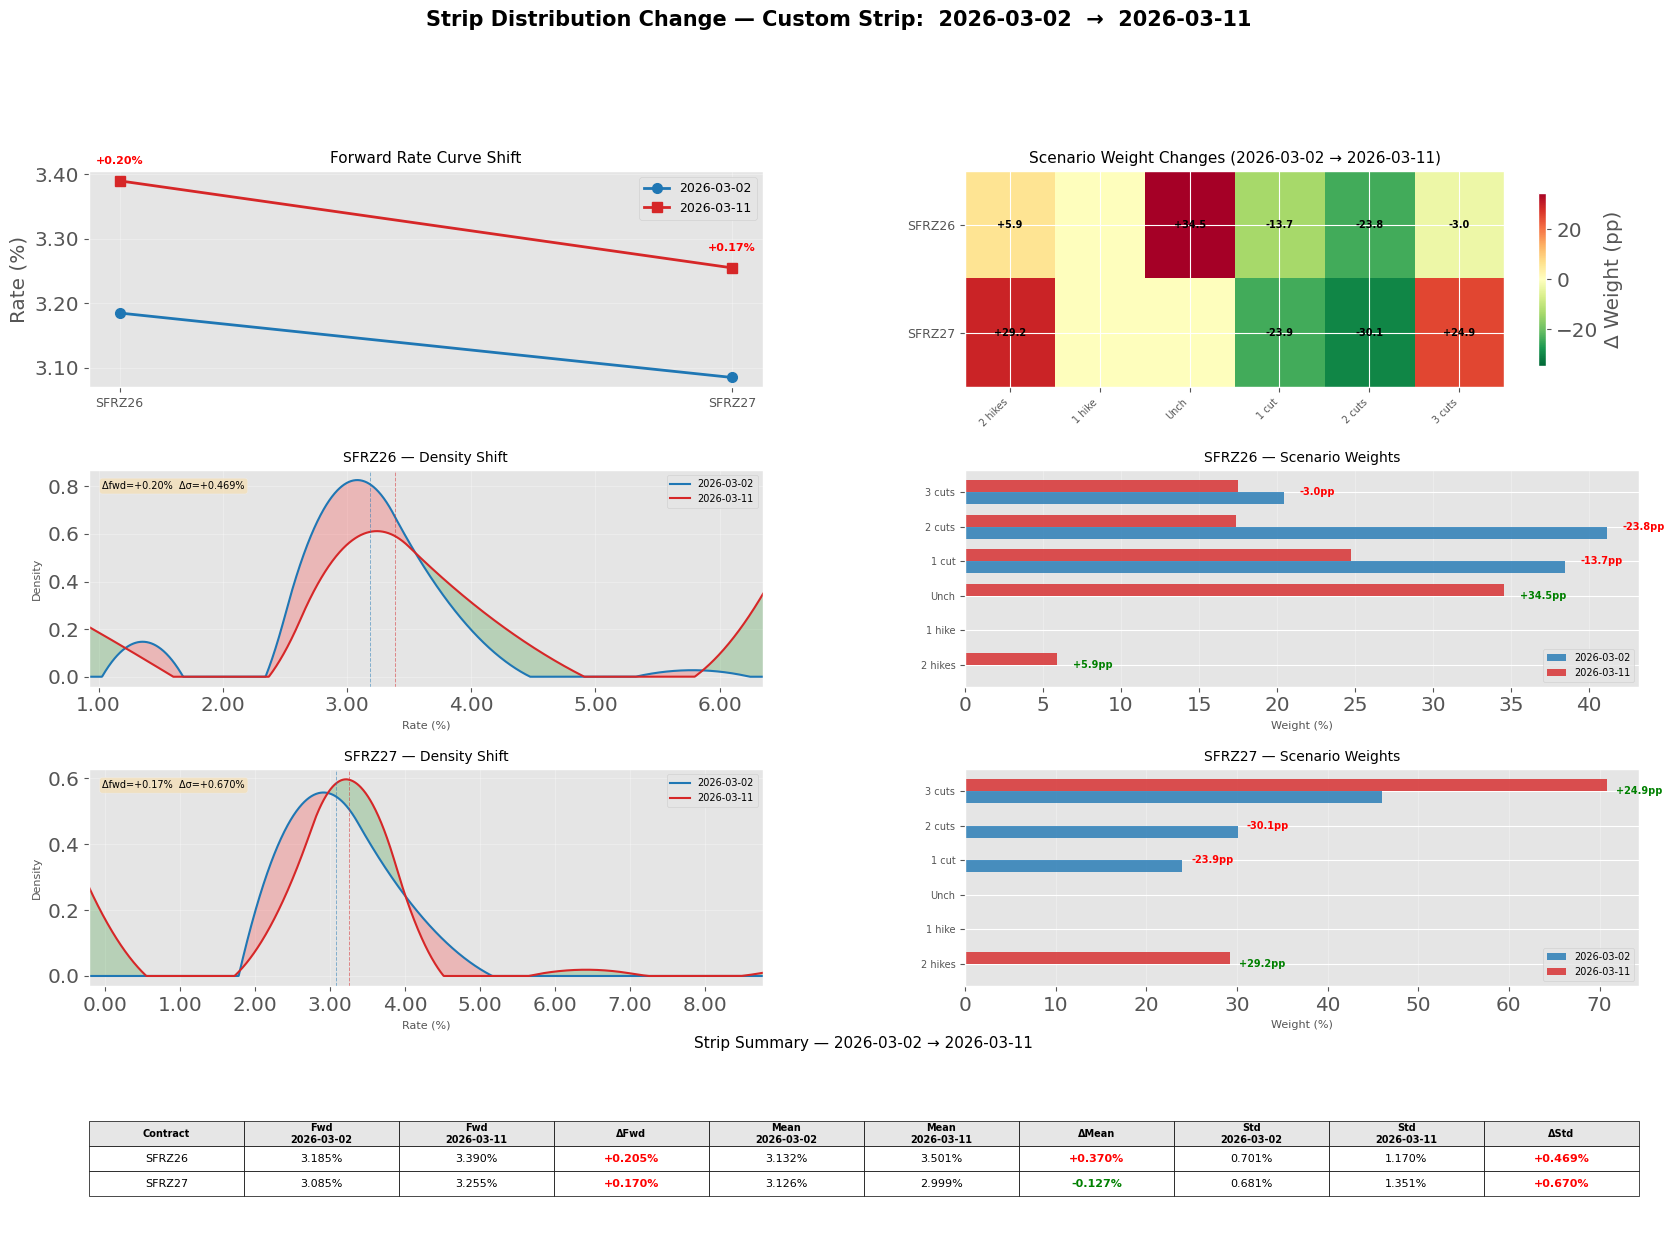

In [13]:
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution,
    FedScenarioConfig,
    resolve_strip_symbols,
    plot_strip_distribution_change,
)
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP

mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

date1 = datetime.date(2026, 3, 2)
date2 = datetime.date(2026, 3, 11)

syms = ["SFRZ26", "SFRZ27"]
# syms = resolve_strip_symbols("whites", as_of=date2)

# Fetch smiles at both dates
smiles_d1 = {s: mdp.fetch_sabr_smile({"symbol": s, "as_of": date1, "strike_offsets_bps": "listed"}) for s in syms}
smiles_d2 = {s: mdp.fetch_sabr_smile({"symbol": s, "as_of": date2, "strike_offsets_bps": "listed"}) for s in syms}


scenarios = FedScenarioConfig.default_sofr_scenarios(
    current_rate=3.64,
    n_cuts_range=[-2, -1, 0, 1, 2, 3],
    default_std_bps=None,  # optimize std devs
)

dist = SFRImpliedDistribution(scenario_config=scenarios)
result = dist.compare_strip(smiles_d1, smiles_d2, symbols=syms, as_of=date2)
plot_strip_distribution_change(result)

# Or with explicit symbols:
# result = dist.compare_strip(smiles_d1, smiles_d2, symbols=["SFRZ26", "SFRZ27"])